Links:
 - https://stackoverflow.com/questions/78106951/how-do-i-access-input-devices-on-wsl2
 - https://www.pygame.org/docs/ref/midi.html

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sy
from scipy.io.wavfile import write

In [212]:
def generate_triangle_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = (4/p)*sy.Abs(sy.Mod(x - p/4, p) - p/2) - 1
    return sy.lambdify(x, y, "numpy")

def generate_sawtooth_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = 2*(x/p - sy.floor(1/2 + x/p))
    return sy.lambdify(x, y, "numpy")

def generate_square_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = (-1)**sy.floor(2*x/p)
    return sy.lambdify(x, y, "numpy")

triangle_wave = generate_triangle_wave()
sawtooth_wave = generate_sawtooth_wave()
square_wave = generate_square_wave()

class Oscillator():
    def __init__(self, waveform = "sine", pitch = "C4", volume = 1, sample_rate = 44100):
        musical_alphabet = ["C", "C#/Db", "D", "Eb/D#", "E", "F", "F#/Gb", "G", "Ab/G#", "A", "Bb/A#", "B"]
        frequencies = [440*(2**((m - 69)/12)) for m in range(12, 120)]
        self.notes_lut = {}
        octaves = (np.floor(np.arange(12, 120)/12) - 1).astype(int)
        for index, (frequency, octave) in enumerate(zip(frequencies, octaves)):
            note = musical_alphabet[index%12] + str(octave)
            self.notes_lut[note] = frequency
        self.waveform = waveform
        self.pitch = pitch
        self.volume = volume
        self.sample_rate = sample_rate
    
    def generate_pitch(self, duration = None, samples = None):
        if duration and samples:
            raise Exception("Both duration and samples cannot be specified!")
        elif not duration and not samples:
            raise Exception("Either duration or samples must be specified!")
        elif duration:
            samples = int(self.sample_rate*duration)
        elif samples:
            duration = samples/self.sample_rate
        if self.pitch is None:
            return np.zeros(samples)
        else:
            return self.volume*self.waveform(np.linspace(0, self.pitch*duration*2*np.pi, samples))
    
    @property
    def pitch(self):
        return self._pitch
    @pitch.setter
    def pitch(self, pitch):
        if type(pitch) in [str, np.str_]:
            self._pitch = self.notes_lut[pitch.upper()]
        elif type(pitch) in [int, float]:
            self._pitch = pitch
        elif pitch is None:
            self._pitch = None
        else:
            raise Exception("Invalid pitch! Must be either a string, a number or None!")
    
    @property
    def waveform(self):
        return self._waveform
    @waveform.setter
    def waveform(self, waveform):
        if waveform == "sine":
            self._waveform = np.sin
        elif waveform == "triangle":
            self._waveform = triangle_wave
        elif waveform == "sawtooth":
            self._waveform = sawtooth_wave
        elif waveform == "square":
            self._waveform = square_wave
        else:
            raise Exception("Invalid waveform!, must be either 'sine', 'triangle', 'sawtooth' or 'square'!")

class Filter():
    def __init__(self, kernel_type = "low-pass", duration = 25e-3, width = 2, sample_rate = 44100):
        self.duration = duration
        self.width = width
        self.sample_rate = sample_rate
        self.kernel_type = kernel_type
        self.kernel = self._kernel_low_pass()

    def _kernel_low_pass(self):
        def gaussian(x, sigma):
            return np.exp(-0.5*x**2/(sigma**2))
        width = self.width*2*np.pi
        samples = int(self.duration*self.sample_rate)
        domain = np.linspace(-width/2, width/2, samples)
        kernel = np.sinc(domain)*gaussian(domain, width/6)
        return kernel/np.abs(np.fft.fft(kernel)[0])
    
    def apply(self, wave):
        return np.convolve(wave, self.kernel, mode = "same")

    @property
    def kernel_type(self):
        return self._kernel_type
    @kernel_type.setter
    def kernel_type(self, kernel_type):
        if kernel_type.lower() not in ["low-pass"]:
            raise Exception("Invalid kernel type! Must be either 'low-pass', some other type, another type, yet another, etc.!")
        self._kernel_type = kernel_type
        if hasattr(self, "kernel"):
            self.kernel = self._kernel_low_pass()
    
    @property
    def duration(self):
        return self._duration
    @duration.setter
    def duration(self, duration):
        self._duration = duration
        if hasattr(self, "kernel"):
            self.kernel = self._kernel_low_pass()
    
    @property
    def width(self):
        return self._width
    @width.setter
    def width(self, width):
        self._width = width
        if hasattr(self, "kernel"):
            self.kernel = self._kernel_low_pass()
    
    @property
    def sample_rate(self):
        return self._sample_rate
    @sample_rate.setter
    def sample_rate(self, sample_rate):
        self._sample_rate = sample_rate
        if hasattr(self, "kernel"):
            self.kernel = self._kernel_low_pass()

class Bar():
    def __init__(self, notes, note_values, time_signature = (4, 4)):
        self.notes = notes
        self.note_values = note_values
        self.time_signature = time_signature
        self._exception_check()
    
    def _exception_check(self):
        if np.array([True if hasattr(self, attribute) else False for attribute in ["notes", "note_values", "time_signature"]]).all():
            if self.notes.size != self.note_values.size:
                raise Exception("Number of notes must be equal to the number of note values!")
            elif self.notes.size < self.time_signature[0]:
                raise Exception("Too few notes in the bar!")
            elif self.notes.size > self.time_signature[0]:
                raise Exception("Too many notes in the bar!")
            elif self.note_values.sum() != self.time_signature[0]/self.time_signature[1]:
                raise Exception("Note values must sum to the length of the bar specified in the time signature!")
    
    @property
    def notes(self):
        return self._notes
    @notes.setter
    def notes(self, notes):
        self._notes = np.array(notes) if type(notes) != np.ndarray else notes
        self._exception_check()
    
    @property
    def note_values(self):
        return self._note_values
    @note_values.setter
    def note_values(self, note_values):
        self._note_values = np.array(note_values) if type(note_values) != np.ndarray else note_values
        self._exception_check()

def calculate_note_sample_masks(bar, bpm, sample_rate = 44100):
    bar_duration = bar.time_signature[0]*60/bpm
    bar_samples = int(bar_duration*sample_rate)
    beat_samples = bar_samples*bar.time_signature[1]/bar.time_signature[0]
    note_sample_mask = np.full((bar.notes.size, bar_samples), False)
    for index, note_value in enumerate(bar.note_values):
        mask_start = np.floor(bar.note_values[:index].sum()*beat_samples).astype(int)
        mask_end = mask_start + np.floor(note_value*beat_samples).astype(int)
        note_sample_mask[index, mask_start:mask_end] = True
    return note_sample_mask

def generate_wave(bar, oscillators, filters, bpm, sample_rate = 44100):
    if type(oscillators) not in [list, tuple]:
        oscillators = [oscillators for _ in range(bar.notes.size)]
    if type(filters) not in [list, tuple]:
        filters = [filters for _ in range(bar.notes.size)]
    note_sample_masks = calculate_note_sample_masks(bar, bpm, sample_rate = sample_rate)
    waves = np.zeros(note_sample_masks.shape)
    for index, note_sample_mask in enumerate(note_sample_masks):
        note_samples = note_sample_mask.sum()
        if oscillators[index] is not None:
            oscillators[index].pitch = bar.notes[index]
            wave = oscillators[index].generate_pitch(samples = note_samples)
        else:
            wave = np.zeros(note_samples)
        if filters[index] is not None:
            wave = filters[index].apply(wave)
        waves[index][note_sample_mask] = wave
    return waves.sum(0)

def generate_pause(value, time_signature, bpm, sample_rate = 44100):
    duration = value*time_signature[1]*60/bpm
    samples = int(duration*sample_rate)
    return np.zeros(samples)

def save(file_name, array_input, sample_rate = 44100):
    array_input_range = np.ptp(array_input)
    if array_input.ndim == 2:
        array_output = array_input.sum(0)
    else:
        array_output = array_input.copy()
    array_output -= array_output.min()
    array_output *= (2**32 - 1)/array_output.max()
    array_output -= (2**32)//2
    array_output *= array_input_range/2
    array_output = np.clip(np.floor(array_output), -2**32//2, 2**32//2 - 1).astype(np.int32).T
    if file_name[-4:] != ".wav":
        file_name += ".wav"
    write(file_name, sample_rate, array_output)

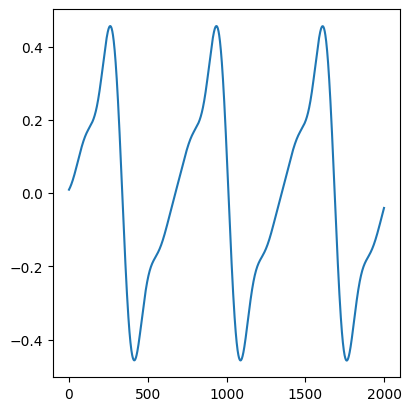

In [215]:
bpm = 120
time_signature = (3, 4)
sample_rate = 44100

bar_0 = Bar(notes = ["C2", "C3", "C4"], note_values = [1/2, 1/8, 1/8], time_signature = time_signature)
oscillators_0 = Oscillator(waveform = "sawtooth", pitch = None, volume = 0.5, sample_rate = sample_rate)
filters_0 = Filter(kernel_type = "low-pass", duration = 25e-3, width = 2, sample_rate = sample_rate)
wave_0 = generate_wave(bar_0, oscillators_0, filters_0, bpm, sample_rate)

wave_1 = generate_pause(3/4, time_signature, bpm, sample_rate)

bar_2 = Bar(notes = ["C3", "C4", "C3"], note_values = [1/2, 1/8, 1/8], time_signature = time_signature)
oscillators_2 = Oscillator(waveform = "sawtooth", pitch = None, volume = 0.5, sample_rate = sample_rate)
filters_2 = Filter(kernel_type = "low-pass", duration = 25e-3, width = 2, sample_rate = sample_rate)
wave_2 = generate_wave(bar_2, oscillators_2, filters_2, bpm, sample_rate)

wave = np.concatenate((wave_0, wave_1, wave_2))

figure, axis = plt.subplots(1, 1, figsize = (4, 4), layout = "constrained")
axis.plot(wave[:2000])

save("test", wave)

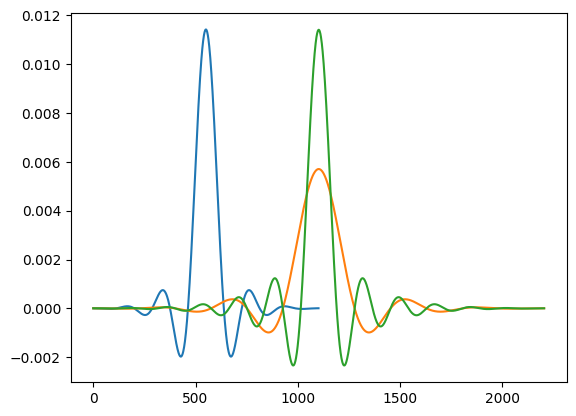

In [ ]:

    
f = filter("low-pass", 25e-3, 2, 44100)
plt.plot(f.kernel)
f.duration *= 2
plt.plot(f.kernel)
f.width *= 2
plt.plot(f.kernel)

In [61]:
np.abs(np.fft.fft(kernel)[0])

175.33720971718574

In [183]:
from scipy.ndimage import gaussian_filter

def adsr(a = 1, d = 1, s = 1, r = 1, s_level = 0.5, duration = 1, amplitude = 1, sampling_rate = 44100):
    if duration != 0:
        total = np.sum([a, d, s, r])
        a /= total
        d /= total
        s /= total
        r /= total
        attack = gaussian_filter(np.linspace(0, 1, int(sampling_rate*duration*a)), 1000)
        attack -= attack.min()
        attack /= attack.max()
        decay = gaussian_filter(np.linspace(1, 0, int(sampling_rate*duration*d)), 1000)
        decay -= decay.min()
        decay /= decay.max()/(1 - s_level)
        decay += s_level
        sustain = np.full(int(sampling_rate*duration*s), 1, dtype = float)
        sustain *= s_level
        release = gaussian_filter(np.linspace(1, 0, int(sampling_rate*duration*r)), 1000)
        release -= release.min()
        release /= release.max()/s_level
        envelope = np.concatenate([attack, decay, sustain, release])
        if envelope.shape[0] != int(duration*sampling_rate):
            envelope = np.concatenate([envelope, np.zeros((np.abs(int(duration*sampling_rate) - envelope.shape[0])))])
        return envelope*amplitude
    else:
        return np.zeros(1)

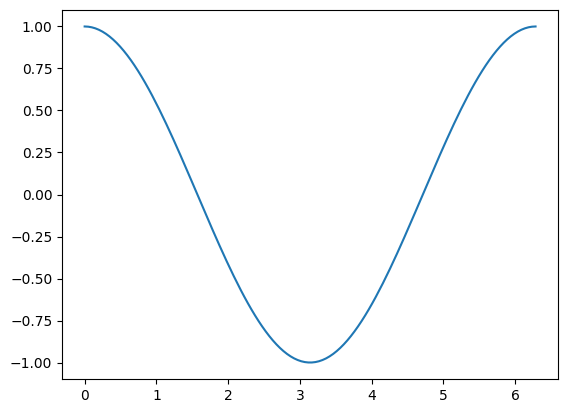

In [224]:
x = np.linspace(0, 2*np.pi, 128)
end = 2*np.pi
plt.plot(x, np.cos(2*np.pi*x/end))

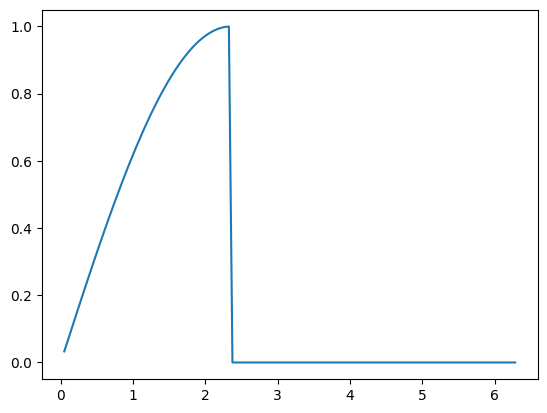

In [213]:
def adsr_sy():
    x, pi = sy.symbols("x"), sy.pi
    attack_start, attack_end = 0, 3*pi/4
    y = sy.Piecewise((0, (x < attack_start)), (sy.sin(pi/2*x/attack_end), (attack_start < x) & (x <= attack_end)), (0, (attack_end < x)))
    return sy.lambdify(x, y, "numpy")
f = adsr_sy()
x = np.linspace(0, 2*np.pi, 128)
plt.plot(x, f(x))

In [184]:
a = adsr()

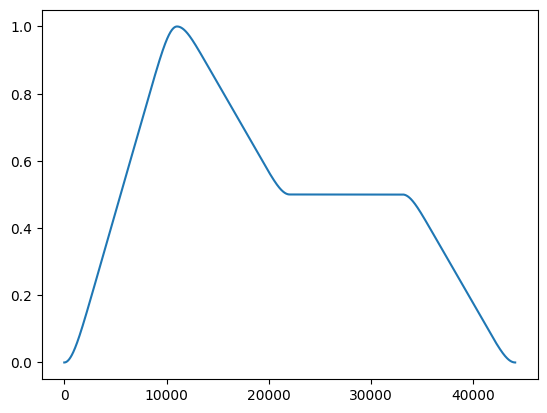

In [185]:
plt.plot(a)

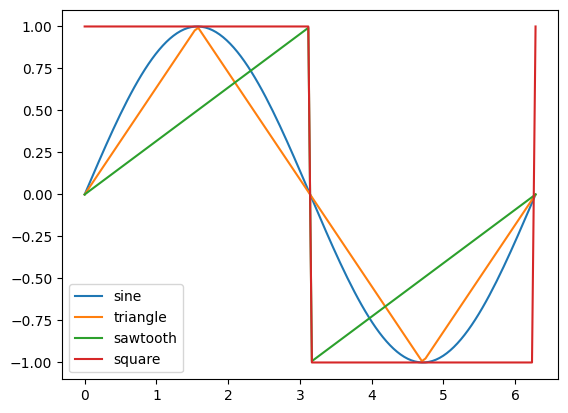

In [187]:
def generate_triangle_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = (4/p)*sy.Abs(sy.Mod(x - p/4, p) - p/2) - 1
    return sy.lambdify(x, y, "numpy")

def generate_sawtooth_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = 2*(x/p - sy.floor(1/2 + x/p))
    return sy.lambdify(x, y, "numpy")

def generate_square_wave():
    x, p = sy.symbols("x"), 2*sy.pi
    y = (-1)**sy.floor(2*x/p)
    return sy.lambdify(x, y, "numpy")

triangle_wave = generate_triangle_wave()
sawtooth_wave = generate_sawtooth_wave()
square_wave = generate_square_wave()

amplitude, frequency, phase = 1, 1, 0

x = np.linspace(0, 2*np.pi, 128)
plt.plot(x, amplitude*np.sin(frequency*x + phase), label = "sine")
plt.plot(x, amplitude*triangle_wave(frequency*x + phase), label = "triangle")
plt.plot(x, amplitude*sawtooth_wave(frequency*x + phase), label = "sawtooth")
plt.plot(x, amplitude*square_wave(frequency*x + phase), label = "square")
plt.legend()